***Title: Exploratory Data Analysis (EDA) on Employee Performance***

1. Import Libraries and Set Styling

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

2. Load and Prepare the Dataset

In [6]:
df = pd.read_csv('employees.csv')
df['date'] = pd.to_datetime(df['date'])
df['month_str'] = df['date'].dt.strftime('%Y-%m')

print("Dataset: 3600 rows, 60 employees, Jan-Feb 2024")

Dataset: 3600 rows, 60 employees, Jan-Feb 2024


3. Q1: Department Averages

In [16]:
dept_avg = df.groupby('department')[['tasks_completed', 'hours_worked']].mean().round(2)
print("\n Dept Averages:\n", dept_avg)


 Dept Averages:
              tasks_completed  hours_worked
department                                
Engineering             7.06          7.20
Finance                 5.25          7.15
HR                      5.25          7.21
Marketing               6.11          7.01
Sales                   8.97          7.17
Support                11.02          7.27


4. Q2: Correlation Analysis

In [12]:
overall_corr = df[['rating', 'projects', 'absences']].corr().round(2)
print("\n Overall Corr:\n", overall_corr)

role_corr_proj = df.groupby('role').apply(lambda x: x['rating'].corr(x['projects'])).sort_values(ascending=False).round(2).head()
role_corr_abs = df.groupby('role').apply(lambda x: x['rating'].corr(x['absences'])).sort_values().round(2).head()

print("\nRole Rating-Projects (top):", role_corr_proj)
print("Role Rating-Absences (worst):", role_corr_abs)


 Overall Corr:
           rating  projects  absences
rating      1.00      0.07     -0.84
projects    0.07      1.00      0.02
absences   -0.84      0.02      1.00

Role Rating-Projects (top): role
Designer      0.09
AE            0.08
QA Eng        0.05
SEO           0.04
Accountant    0.02
dtype: float64
Role Rating-Absences (worst): role
Frontend Dev   -0.93
Analyst        -0.89
QA Eng         -0.89
Backend Dev    -0.89
SEO            -0.88
dtype: float64


5. Q3: Top Performing Employees

In [15]:
emp_rating = df.groupby('employee_id')['rating'].mean().sort_values(ascending=False).head(5).round(2)
print("\n Top 5 Rating:\n", emp_rating)

top_emps = emp_rating.index.tolist()
top_trends = df[df['employee_id'].isin(top_emps)].groupby(['employee_id', 'month_str'])['rating'].mean().round(2)


 Top 5 Rating:
 employee_id
E1005    4.14
E1040    4.09
E1041    4.06
E1042    4.00
E1021    3.98
Name: rating, dtype: float64


6. Q4: Absence Rates

In [17]:

abs_rate_dept = (df.groupby('department')['absences'].mean() * 100).round(2).sort_values(ascending=False)
abs_rate_role = (df.groupby('role')['absences'].mean() * 100).round(2).sort_values(ascending=False).head(10)

print("\n Abs % Dept:\n", abs_rate_dept)
print("Abs % Roles (top):\n", abs_rate_role)


 Abs % Dept:
 department
Sales          5.00
Support        4.67
Marketing      4.63
Engineering    4.62
Finance        4.33
HR             3.89
Name: absences, dtype: float64
Abs % Roles (top):
 role
Frontend Dev       8.33
Account Manager    5.83
SEO                5.42
Analyst            5.00
Backend Dev        5.00
Team Lead          5.00
SDR                4.58
Agent              4.58
AE                 4.44
QA Eng             4.17
Name: absences, dtype: float64


7. Q5: Monthly Productivity

In [18]:
monthly_prod = df.groupby('month_str')['tasks_completed'].mean().round(2)
print("\n Monthly Tasks:\n", monthly_prod)


 Monthly Tasks:
 month_str
2024-01    6.93
2024-02    6.93
Name: tasks_completed, dtype: float64


8. Export Data Summaries to CSV

In [19]:
summary_data = {
    'dept_averages.csv': dept_avg,
    'correlations.csv': overall_corr,
    'top_employees.csv': emp_rating,
    'abs_dept.csv': abs_rate_dept,
    'abs_roles.csv': abs_rate_role,
    'monthly_prod.csv': monthly_prod,
    'top_trends.csv': top_trends.reset_index(),
    'overall_stats.csv': df.describe().round(2)
}

for fname, data in summary_data.items():
    data.to_csv(fname)
    print(f"Saved: {fname}")

Saved: dept_averages.csv
Saved: correlations.csv
Saved: top_employees.csv
Saved: abs_dept.csv
Saved: abs_roles.csv
Saved: monthly_prod.csv
Saved: top_trends.csv
Saved: overall_stats.csv


9. Generate EDA Visualizations Dashboard

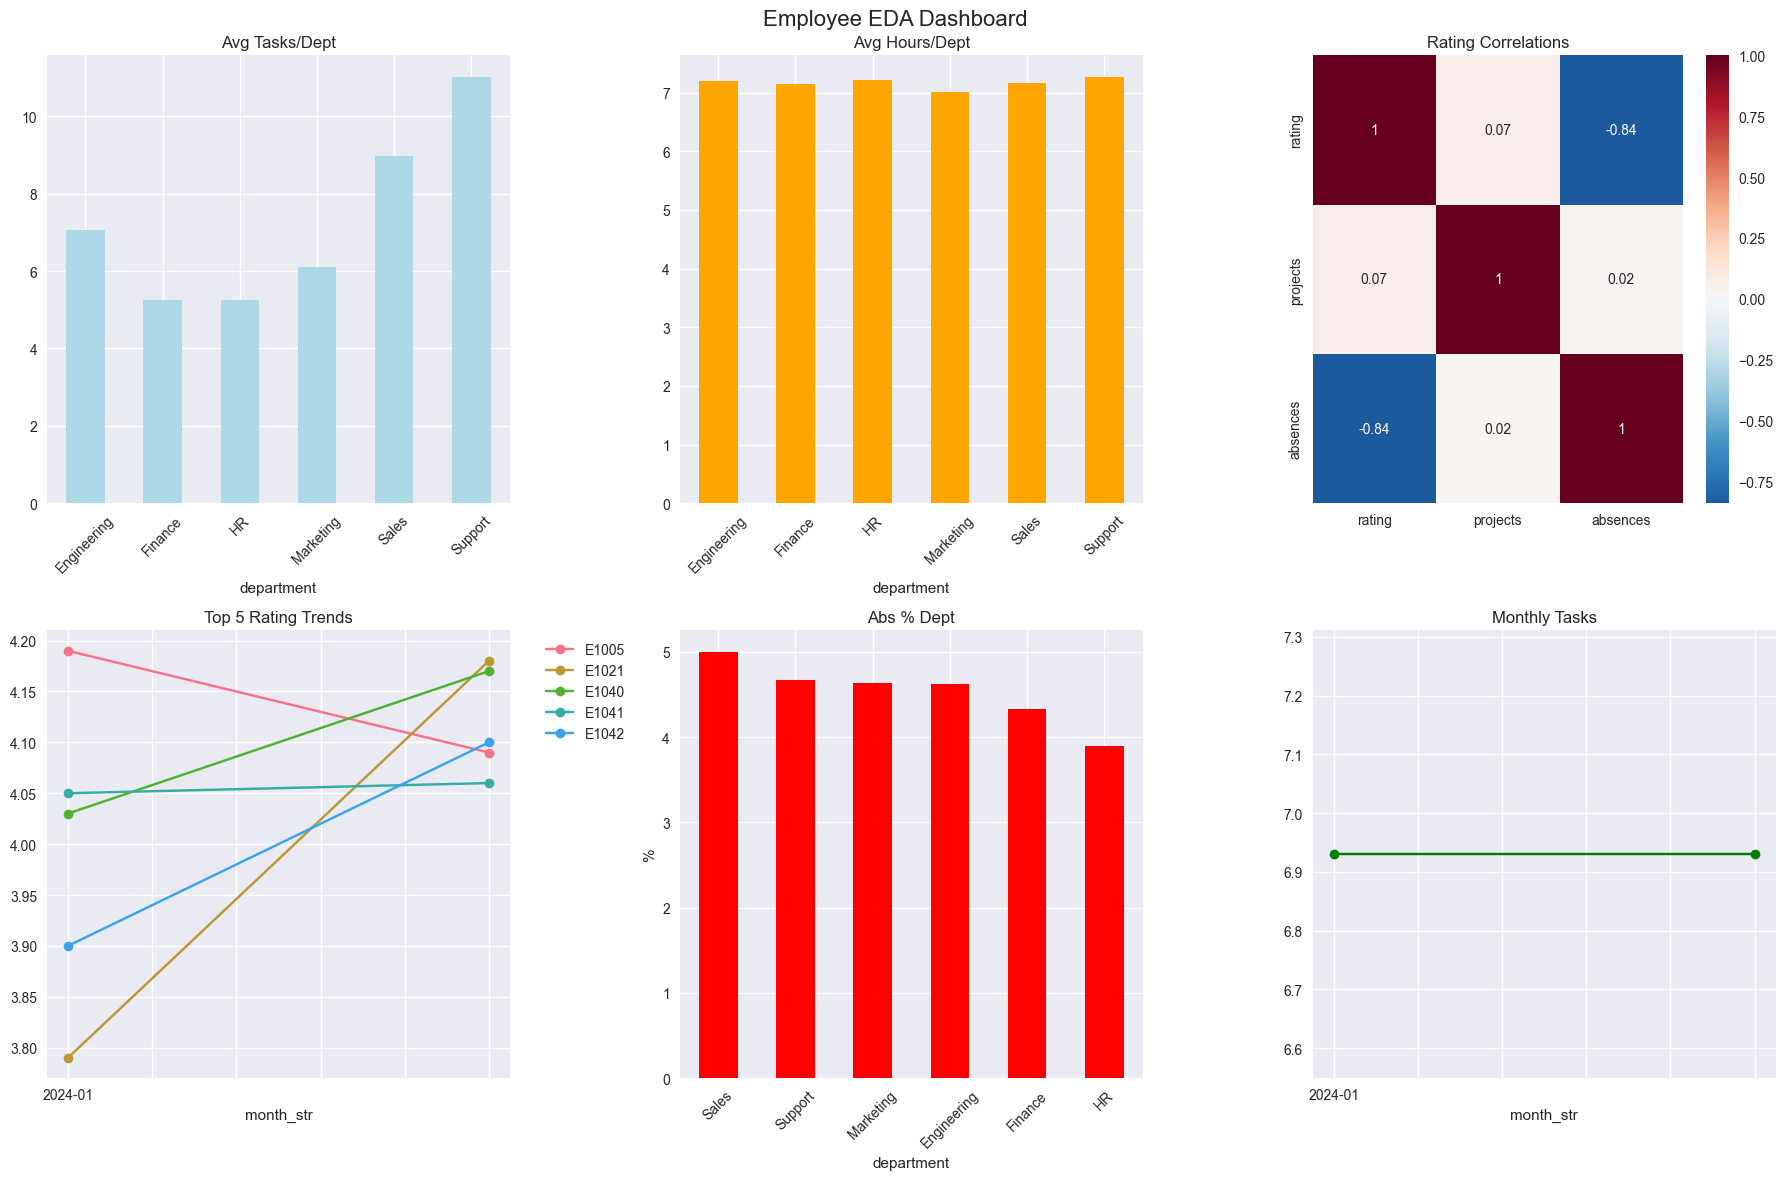


 Completed sucessfully!


In [20]:
# Visualizations (PNG outputs)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Employee EDA Dashboard', fontsize=16)

# 1. Dept bars
dept_avg['tasks_completed'].plot(kind='bar', ax=axes[0,0], title='Avg Tasks/Dept', color='lightblue')
axes[0,0].tick_params(axis='x', rotation=45)
dept_avg['hours_worked'].plot(kind='bar', ax=axes[0,1], title='Avg Hours/Dept', color='orange')
axes[0,1].tick_params(axis='x', rotation=45)

# 2. Corr heatmap
sns.heatmap(overall_corr, annot=True, cmap='RdBu_r', center=0, ax=axes[0,2])
axes[0,2].set_title('Rating Correlations')

# 3. Top trends
top_trends_pivot = top_trends.reset_index().pivot(index='month_str', columns='employee_id', values='rating')
top_trends_pivot.plot(kind='line', marker='o', ax=axes[1,0], title='Top 5 Rating Trends')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Abs bars
abs_rate_dept.plot(kind='bar', ax=axes[1,1], title='Abs % Dept', color='red')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_ylabel('%')

# 5. Monthly line
monthly_prod.plot(kind='line', marker='o', ax=axes[1,2], title='Monthly Tasks', color='green')
plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Completed sucessfully!")
